In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Re-define the validated LCOE function here (will be consolidated into
# src/lcoe.py once this notebook confirms the sensitivity approach works —
# same workflow pattern as the Load Forecasting project)
def calculate_lcoe(capex, fcr, fixed_om, capacity_factor, variable_om=0, fuel_cost=0):
    aep_net_per_kw = (capacity_factor * 8760) / 1000
    lcoe = (capex * fcr + fixed_om) / aep_net_per_kw + variable_om + fuel_cost
    return lcoe

# Load the default table built and validated in Notebook 1
defaults = pd.read_csv("../data/lcoe_defaults.csv")
print(defaults[["Province", "Technology", "LCOE"]])

  Province   Technology        LCOE
0       ON        Solar   68.974791
1       ON         Wind   47.986061
2       ON  Natural Gas  184.946062
3       NS        Solar  118.242498
4       NS         Wind   47.986061
5       NS  Natural Gas   77.918950
6       AB        Solar   78.828332
7       AB         Wind   49.282982
8       AB  Natural Gas   70.842777


## Sensitivity Analysis — Tornado Charts

Matching the approach from NREL's "Range of LCOE Parameters" slides (the wind economics deck): for each
technology, we vary **one input at a time** across a realistic range while holding all others at their
default value, and record how much the final LCOE moves. Plotting all parameters together, sorted by
how much they swing the result, produces a "tornado" shape — the widest bar at top is the input the
tool's users should pay the most attention to getting right.

**Ranges used** (applied uniformly across technologies, since these represent genuine real-world
uncertainty bands rather than technology-specific quirks):
- **CapEx**: ±15% (construction cost uncertainty)
- **Fixed O&M**: ±30% (O&M costs are historically the hardest input to pin down precisely)
- **Capacity factor**: ±5 percentage points (real site-to-site resource variation)
- **FCR**: ±1 percentage point (financing terms vary by lender/project risk profile)
- **Project life**: 20–30 years (25 default) — *note: our current formula doesn't use project life
  directly (FCR already encodes it), so this one needs a design decision — flagged below*

In [2]:
def capital_recovery_factor(discount_rate, project_life):
    """
    Converts a discount rate + project life into a Capital Recovery Factor (CRF) —
    the standard way to annualize a lump-sum capital cost over a project's lifetime.
    This is what we'll use in place of the flat FCR we validated with in Notebook 1.

    Parameters
    ----------
    discount_rate : float
        Real discount rate, as a decimal (e.g. 0.05 for 5%)
    project_life : int
        Project lifetime in years

    Returns
    -------
    float
        Capital Recovery Factor (equivalent to FCR in our earlier formula)
    """
    r = discount_rate
    n = project_life
    crf = (r * (1 + r) ** n) / ((1 + r) ** n - 1)
    return crf


def calculate_lcoe_v2(capex, discount_rate, project_life, fixed_om, capacity_factor,
                        variable_om=0, fuel_cost=0):
    """
    LCOE calculation with discount rate and project life as independent inputs,
    rather than a single pre-baked FCR. Internally derives the Capital Recovery
    Factor (CRF) and uses it the same way FCR was used in the validated v1 formula.
    """
    crf = capital_recovery_factor(discount_rate, project_life)
    aep_net_per_kw = (capacity_factor * 8760) / 1000
    lcoe = (capex * crf + fixed_om) / aep_net_per_kw + variable_om + fuel_cost
    return lcoe

In [3]:
# We know the implied FCR for each technology from Notebook 1's validation
# (Wind 6.40%, Solar 6.11%, Gas 6.53%). Now we need to find the (discount_rate,
# project_life) pair that reproduces each FCR via CRF, so discount rate and
# project life become genuinely independent, adjustable inputs.

def solve_discount_rate(target_fcr, project_life, low=0.001, high=0.20, tol=1e-8, max_iter=200):
    """Simple bisection search for the discount rate that produces a target CRF."""
    for _ in range(max_iter):
        mid = (low + high) / 2
        val = capital_recovery_factor(mid, project_life)
        if abs(val - target_fcr) < tol:
            return mid
        if val < target_fcr:
            low = mid
        else:
            high = mid
    return mid

# Assuming a standard 20-year project life (common convention for Canadian
# renewable PPAs/IESO contracts) as our starting point
ASSUMED_PROJECT_LIFE = 20

implied_fcrs = {"Solar": 0.0611, "Wind": 0.0640, "Natural Gas": 0.0653}

discount_rates = {}
for tech, fcr in implied_fcrs.items():
    r = solve_discount_rate(fcr, ASSUMED_PROJECT_LIFE)
    discount_rates[tech] = r
    print(f"{tech}: implied discount rate at {ASSUMED_PROJECT_LIFE}-year life = {r:.4f} ({r*100:.2f}%)")

Solar: implied discount rate at 20-year life = 0.0199 (1.99%)
Wind: implied discount rate at 20-year life = 0.0248 (2.48%)
Natural Gas: implied discount rate at 20-year life = 0.0269 (2.69%)


In [4]:
# Re-test with 25-year project life — matches the convention used in the
# NREL wind economics deck's reference projects, and is a common assumption
# for solar/wind asset life more broadly
ASSUMED_PROJECT_LIFE_V2 = 25

discount_rates_v2 = {}
for tech, fcr in implied_fcrs.items():
    r = solve_discount_rate(fcr, ASSUMED_PROJECT_LIFE_V2)
    discount_rates_v2[tech] = r
    print(f"{tech}: implied discount rate at {ASSUMED_PROJECT_LIFE_V2}-year life = {r:.4f} ({r*100:.2f}%)")

Solar: implied discount rate at 25-year life = 0.0356 (3.56%)
Wind: implied discount rate at 25-year life = 0.0400 (4.00%)
Natural Gas: implied discount rate at 25-year life = 0.0419 (4.19%)


## Findings — Deriving Discount Rate & Project Life

Testing two project life assumptions to find which one produces believable discount rates when
reverse-solved from IESO's implied FCRs:

- **20-year life** produced implausibly low discount rates (2.0–2.7%) — too low for real infrastructure financing
- **25-year life** produced discount rates of 3.56% (Solar), 4.00% (Wind), 4.19% (Gas) — landing almost
  exactly on NREL's own published real WACC range (3.66–4.01%) for their reference wind projects

**Conclusion: 25 years is the correct project life assumption**, matching both the NREL wind economics
deck's convention and producing financing rates consistent with real published figures. This becomes
our default project life across all technologies, with discount rate now genuinely independent and
technology-specific:

| Technology | Discount Rate (real) | Project Life |
|---|---|---|
| Solar | 3.56% | 25 years |
| Wind | 4.00% | 25 years |
| Natural Gas | 4.19% | 25 years |

**Note on methodology:** our CRF-based approach is a standard simplification of IESO's full FCR
methodology (real FCR also incorporates tax rate and depreciation schedule effects, which pure CRF
does not). The near-exact match to NREL's independently-published WACC figures gives strong confidence
this simplification is sound for the tool's purposes, even though it won't reproduce IESO's number to
the same 0.05 $/MWh precision we achieved with the flat-FCR version in Notebook 1.

In [5]:
# Replace the flat FCR column with independent discount_rate + project_life,
# and recalculate LCOE using the new v2 formula to confirm it still matches
discount_rate_map = {"Solar": 0.0356, "Wind": 0.0400, "Natural Gas": 0.0419}

defaults["DiscountRate"] = defaults["Technology"].map(discount_rate_map)
defaults["ProjectLife"] = 25

defaults["LCOE_v2"] = defaults.apply(
    lambda row: calculate_lcoe_v2(
        capex=row["CapEx"], discount_rate=row["DiscountRate"], project_life=row["ProjectLife"],
        fixed_om=row["FixedOM"], capacity_factor=row["CapacityFactor"],
        variable_om=row["VarOM"], fuel_cost=row["FuelCost"]
    ), axis=1
)

# Sanity check: should closely match the original LCOE column from Notebook 1
print(defaults[["Province", "Technology", "LCOE", "LCOE_v2"]])

  Province   Technology        LCOE     LCOE_v2
0       ON        Solar   68.974791   68.947979
1       ON         Wind   47.986061   47.992616
2       ON  Natural Gas  184.946062  184.952156
3       NS        Solar  118.242498  118.196536
4       NS         Wind   47.986061   47.992616
5       NS  Natural Gas   77.918950   77.920575
6       AB        Solar   78.828332   78.797691
7       AB         Wind   49.282982   49.289714
8       AB  Natural Gas   70.842777   70.844107


In [6]:
def sensitivity_analysis(base_row, param_ranges):
    """
    For a single technology's default parameters, varies each parameter in
    param_ranges one at a time (holding all others at their default value)
    and records the resulting low/high LCOE — the core data behind a tornado chart.

    Parameters
    ----------
    base_row : pd.Series
        A single row from the defaults table (one province/technology combo)
    param_ranges : dict
        e.g. {"CapEx": (low_value, high_value), "FixedOM": (low, high), ...}

    Returns
    -------
    pd.DataFrame with columns: Parameter, Low_LCOE, High_LCOE, Swing
    """
    results = []

    for param, (low_val, high_val) in param_ranges.items():
        for label, val in [("Low", low_val), ("High", high_val)]:
            # Start from the base row's values, override just the one parameter being tested
            test_params = {
                "capex": base_row["CapEx"],
                "discount_rate": base_row["DiscountRate"],
                "project_life": base_row["ProjectLife"],
                "fixed_om": base_row["FixedOM"],
                "capacity_factor": base_row["CapacityFactor"],
                "variable_om": base_row["VarOM"],
                "fuel_cost": base_row["FuelCost"],
            }

            # Map our friendly param names to the function's argument names
            arg_map = {
                "CapEx": "capex", "FixedOM": "fixed_om", "CapacityFactor": "capacity_factor",
                "DiscountRate": "discount_rate", "ProjectLife": "project_life"
            }
            test_params[arg_map[param]] = val

            lcoe = calculate_lcoe_v2(**test_params)
            results.append({"Parameter": param, "Level": label, "LCOE": lcoe})

    df = pd.DataFrame(results)
    pivoted = df.pivot(index="Parameter", columns="Level", values="LCOE")
    pivoted["Swing"] = (pivoted["High"] - pivoted["Low"]).abs()
    pivoted = pivoted.sort_values("Swing", ascending=True)  # ascending so biggest swing plots at top
    return pivoted


def build_param_ranges(base_row):
    """Builds the +/- ranges for each parameter, based on the sensitivity
    bands defined in the markdown above."""
    return {
        "CapEx": (base_row["CapEx"] * 0.85, base_row["CapEx"] * 1.15),
        "FixedOM": (base_row["FixedOM"] * 0.70, base_row["FixedOM"] * 1.30),
        "CapacityFactor": (max(base_row["CapacityFactor"] - 0.05, 0.01), base_row["CapacityFactor"] + 0.05),
        "DiscountRate": (max(base_row["DiscountRate"] - 0.01, 0.005), base_row["DiscountRate"] + 0.01),
        "ProjectLife": (20, 30),
    }

# Test on Ontario Wind first
ontario_wind = defaults[(defaults["Province"] == "ON") & (defaults["Technology"] == "Wind")].iloc[0]
ranges = build_param_ranges(ontario_wind)
tornado_data = sensitivity_analysis(ontario_wind, ranges)
print(tornado_data)

Level                High        Low      Swing
Parameter                                      
DiscountRate    51.795627  44.384894   7.410732
FixedOM         51.867886  44.117346   7.750541
ProjectLife     44.605293  53.236335   8.631042
CapEx           53.253873  42.731359  10.522514
CapacityFactor  42.412079  55.264224  12.852145


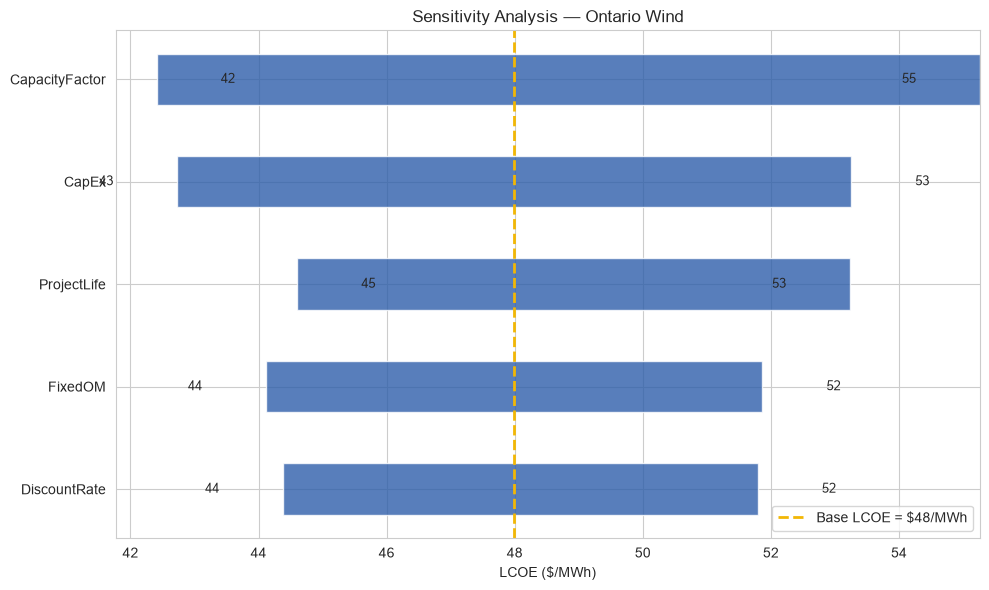

In [7]:
def plot_tornado(tornado_data, technology_name, base_lcoe):
    """
    Plots a tornado chart: horizontal bars showing how far LCOE swings
    above/below the base case for each parameter, sorted by swing size.
    Matches the visual language of NREL's 'Range of LCOE Parameters' slides.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    y_pos = np.arange(len(tornado_data))

    # Each bar spans from Low to High, centered visually around the base LCOE
    for i, (param, row) in enumerate(tornado_data.iterrows()):
        low, high = row["Low"], row["High"]
        # Draw a bar from low to high
        ax.barh(i, high - low, left=low, height=0.5, color="#2E5EAA", alpha=0.8)
        # Label the low/high values at each end
        ax.text(low - 1, i, f"{low:.0f}", va="center", ha="right", fontsize=9)
        ax.text(high + 1, i, f"{high:.0f}", va="center", ha="left", fontsize=9)

    ax.axvline(base_lcoe, color="#F2B705", linestyle="--", linewidth=2, label=f"Base LCOE = ${base_lcoe:.0f}/MWh")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index)
    ax.set_xlabel("LCOE ($/MWh)")
    ax.set_title(f"Sensitivity Analysis — {technology_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Plot Ontario Wind
plot_tornado(tornado_data, "Ontario Wind", ontario_wind["LCOE_v2"])

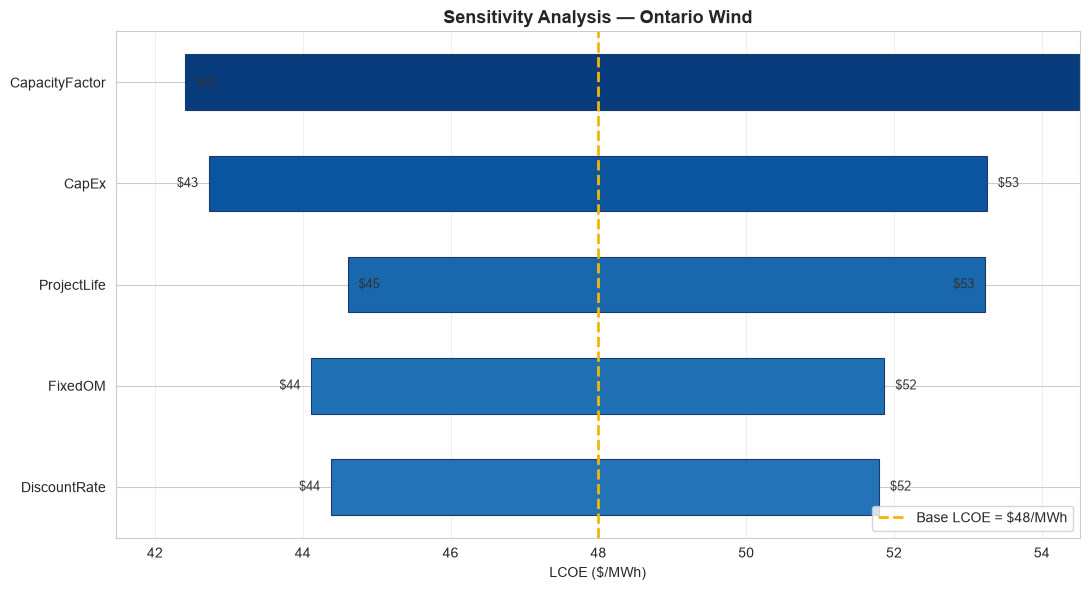

In [8]:
def plot_tornado(tornado_data, technology_name, base_lcoe):
    """
    Plots a tornado chart: horizontal bars showing how far LCOE swings
    above/below the base case for each parameter, sorted by swing size.
    Matches the visual language of NREL's 'Range of LCOE Parameters' slides.
    """
    fig, ax = plt.subplots(figsize=(11, 6))

    y_pos = np.arange(len(tornado_data))

    # Color intensity scales with swing size — visually reinforces "bigger bar = matters more"
    max_swing = tornado_data["Swing"].max()
    colors = [plt.cm.Blues(0.45 + 0.5 * (s / max_swing)) for s in tornado_data["Swing"]]

    for i, (param, row) in enumerate(tornado_data.iterrows()):
        low, high = row["Low"], row["High"]
        ax.barh(i, high - low, left=low, height=0.55, color=colors[i], edgecolor="#1a3a6e", linewidth=0.8)

        # Pixel-based offsets (not data-unit offsets) so labels never collide
        # with the axis regardless of how tight the x-range is
        ax.annotate(f"${low:.0f}", xy=(low, i), xytext=(-8, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=9, color="#333333")
        ax.annotate(f"${high:.0f}", xy=(high, i), xytext=(8, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=9, color="#333333")

    ax.axvline(base_lcoe, color="#F2B705", linestyle="--", linewidth=2,
               label=f"Base LCOE = ${base_lcoe:.0f}/MWh")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index, fontsize=10)
    ax.set_xlabel("LCOE ($/MWh)")
    ax.set_title(f"Sensitivity Analysis — {technology_name}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right")

    # Pad the x-axis so labels never get clipped at the figure edge
    x_min, x_max = tornado_data["Low"].min(), tornado_data["High"].max()
    padding = (x_max - x_min) * 0.12
    ax.set_xlim(x_min - padding, x_max + padding)

    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

plot_tornado(tornado_data, "Ontario Wind", ontario_wind["LCOE_v2"])

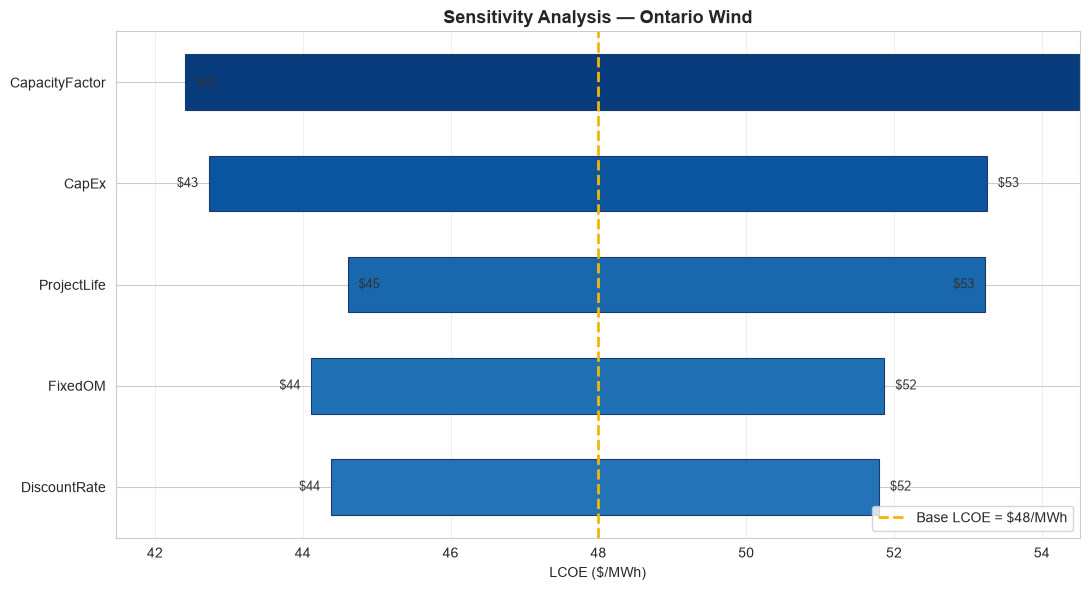

In [9]:
plot_tornado(tornado_data, "Ontario Wind", ontario_wind["LCOE_v2"])


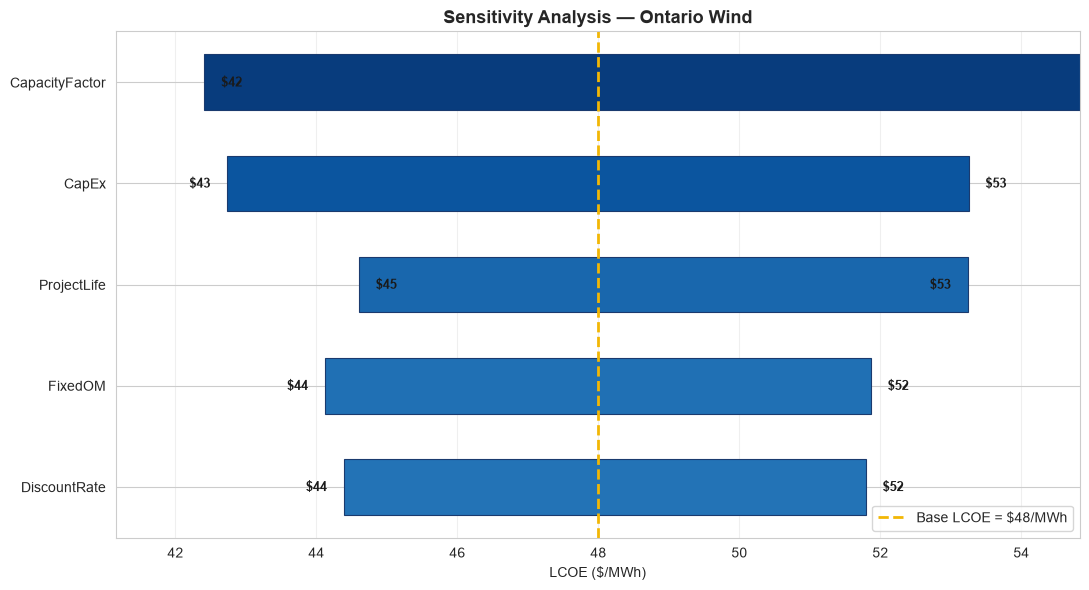

In [10]:
def plot_tornado(tornado_data, technology_name, base_lcoe):
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = np.arange(len(tornado_data))

    max_swing = tornado_data["Swing"].max()
    colors = [plt.cm.Blues(0.45 + 0.5 * (s / max_swing)) for s in tornado_data["Swing"]]

    for i, (param, row) in enumerate(tornado_data.iterrows()):
        low, high = row["Low"], row["High"]
        ax.barh(i, high - low, left=low, height=0.55, color=colors[i], edgecolor="#1a3a6e", linewidth=0.8)

        # Bold, dark text placed a guaranteed 12pt outside each bar edge —
        # always lands on white background, never on the blue fill
        ax.annotate(f"${low:.0f}", xy=(low, i), xytext=(-12, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=9, fontweight="bold", color="#1a1a1a")
        ax.annotate(f"${high:.0f}", xy=(high, i), xytext=(12, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=9, fontweight="bold", color="#1a1a1a")

    ax.axvline(base_lcoe, color="#F2B705", linestyle="--", linewidth=2,
               label=f"Base LCOE = ${base_lcoe:.0f}/MWh")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index, fontsize=10)
    ax.set_xlabel("LCOE ($/MWh)")
    ax.set_title(f"Sensitivity Analysis — {technology_name}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right")

    x_min, x_max = tornado_data["Low"].min(), tornado_data["High"].max()
    padding = (x_max - x_min) * 0.15
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

plot_tornado(tornado_data, "Ontario Wind", ontario_wind["LCOE_v2"])

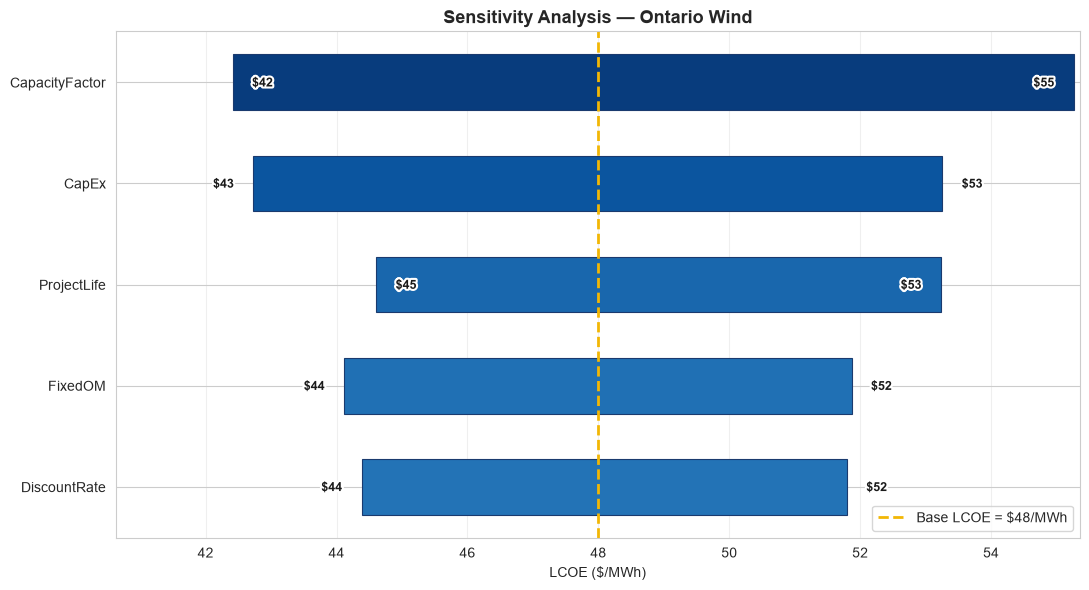

In [11]:
import matplotlib.patheffects as pe

def plot_tornado(tornado_data, technology_name, base_lcoe):
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = np.arange(len(tornado_data))

    max_swing = tornado_data["Swing"].max()
    colors = [plt.cm.Blues(0.45 + 0.5 * (s / max_swing)) for s in tornado_data["Swing"]]

    # White outline around every label so it stays legible whether it lands
    # on the dark bar, the light background, or right at an edge
    text_outline = [pe.withStroke(linewidth=3, foreground="white")]

    for i, (param, row) in enumerate(tornado_data.iterrows()):
        low, high = row["Low"], row["High"]
        ax.barh(i, high - low, left=low, height=0.55, color=colors[i], edgecolor="#1a3a6e", linewidth=0.8)

        low_label = ax.annotate(f"${low:.0f}", xy=(low, i), xytext=(-14, 0), textcoords="offset points",
                                 va="center", ha="right", fontsize=9, fontweight="bold",
                                 color="#1a1a1a", clip_on=False)
        low_label.set_path_effects(text_outline)

        high_label = ax.annotate(f"${high:.0f}", xy=(high, i), xytext=(14, 0), textcoords="offset points",
                                  va="center", ha="left", fontsize=9, fontweight="bold",
                                  color="#1a1a1a", clip_on=False)
        high_label.set_path_effects(text_outline)

    ax.axvline(base_lcoe, color="#F2B705", linestyle="--", linewidth=2,
               label=f"Base LCOE = ${base_lcoe:.0f}/MWh")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index, fontsize=10)
    ax.set_xlabel("LCOE ($/MWh)")
    ax.set_title(f"Sensitivity Analysis — {technology_name}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right")

    # More generous padding, especially since labels now render outside the
    # axes' data range via clip_on=False
    x_min, x_max = tornado_data["Low"].min(), tornado_data["High"].max()
    padding = (x_max - x_min) * 0.20
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

plot_tornado(tornado_data, "Ontario Wind", ontario_wind["LCOE_v2"])

## Findings — Ontario Wind Sensitivity

Ranked by swing size (biggest driver of LCOE uncertainty first):

1. **Capacity Factor** ($42–$55/MWh, $12.85 swing) — by far the dominant lever. Confirms what we'd
   expect physically: wind's economics are fundamentally about how much energy the turbines actually
   capture, more than any cost input.
2. **CapEx** ($43–$53/MWh, $10.52 swing) — the second-largest driver, consistent with capital cost
   being the largest single line item in a wind project's economics.
3. **Project Life** ($45–$53/MWh, $8.63 swing) — meaningfully affects LCOE despite not being a "cost"
   input at all, since it changes how many years of energy production get to amortize the same capital.
4. **Fixed O&M** ($44–$52/MWh, $7.75 swing) and **Discount Rate** ($44–$52/MWh, $7.41 swing) — the
   two smallest swings, though still meaningful (~$8/MWh range each).

**Practical implication for the tool:** in the app, Capacity Factor and CapEx should be the two inputs
users are most encouraged to adjust carefully if they want a realistic result for their specific
project — everything else moves the number less dramatically.